# **2nd ASSIGNMENT**

## Brief introduction

This assignment investigates the transient temperature distribution after 10 seconds within a heat exchanger made of two different materials. The geometry consists of a rectangular metal matrix with six internal tubes carrying tap water at 20°C and 80°C.

## Finite Element Formulation: 2D Transient Heat Conduction

### 1. Governing Equation
The problem is governed by the transient heat diffusion equation in two dimensions. The strong form of the problem:

$$
\rho c_p \frac{\partial T}{\partial t} = \nabla \cdot (\mathbf{D} \nabla T) + s
$$

Where:
* $T(x,y,t)$: Temperature field
* $\rho$: Material density ($kg/m^3$)
* $c_p$: Specific heat capacity ($J/kg K$)
* $\mathbf{D}$: Thermal conductivity tensor (for isotropic materials, $\mathbf{D} = k\mathbf{I}$)
* $s$: Volumetric heat source ($W/m^3$)

### 2. Weak Formulation and Discretization
To solve the problem numerically, we apply the standard Galerkin Finite Element Method. The continuous temperature field is approximated using shape functions $N_i$:

$$
T(x,y,t) \approx \sum_{i=1}^{n} N_i(x,y) T_i(t)
$$

Substituting this approximation into the weak form of the governing equation transforms the Partial Differential Equation (PDE) into a system of Ordinary Differential Equations (ODEs):

$$
\mathbf{M} \dot{\mathbf{T}} + \mathbf{K} \mathbf{T} = \mathbf{F}
$$

Where $\mathbf{M}$ is the global mass matrix (capacity), $\mathbf{K}$ is the global stiffness matrix (conductivity), and $\mathbf{F}$ is the load vector.

### 3. Linear Triangular Element (CST) Implementation

The domain is discretized using 3-node linear triangular elements. For each element $\Omega^e$ with area $A$ and thickness $t$, the element matrices are computed as follows.

#### Stiffness Matrix ($\mathbf{K}^e$)
The stiffness matrix represents the resistance to heat flow. Since the shape functions are linear, their gradients $\nabla \mathbf{N} = \mathbf{B}$ are constant over the element. The integral is evaluated exactly as:

$$
\mathbf{K}^e = \int_{\Omega^e} (\nabla \mathbf{N})^T \mathbf{D} (\nabla \mathbf{N}) \, d\Omega = t \cdot A \cdot (\mathbf{B}^T \mathbf{D} \mathbf{B})
$$

Where $\mathbf{B}$ is the strain-displacement (gradient) matrix depending only on the nodal coordinates.

#### Mass Matrix ($\mathbf{M}^e$)
The mass matrix represents the thermal inertia (heat capacity) of the system. The **Consistent Mass Matrix** is derived by integrating the shape function products over the triangular area:

$$
\mathbf{M}^e = \int_{\Omega^e} \rho c_p \mathbf{N}^T \mathbf{N} \, d\Omega = \frac{\rho c_p A t}{12} 
\begin{bmatrix} 
2 & 1 & 1 \\ 
1 & 2 & 1 \\ 
1 & 1 & 2 
\end{bmatrix}
$$

#### Load Vector ($\mathbf{F}^e$)
The load vector accounts for internal heat generation ($s$) and prescribed heat fluxes ($q_n$) across boundaries. The general definition is:

$$
\mathbf{F}^e = \int_{\Omega^e} \mathbf{N}^T s \, d\Omega + \int_{\Gamma_q^e} \mathbf{N}^T q_n \, d\Gamma
$$

In the specific case of the heat exchanger simulation, the global load vector results in a zero vector ($F=0$) for two reasons:
1.  **No Internal Source:** The volumetric heat source parameter is set to zero ($s = 0$) for all materials (matrix, tubes, and water) in the model definition.
2.  **Boundary Conditions:**
    * The active boundary conditions are **Dirichlet** (fixed temperatures of 20°C and 80°C), which are enforced directly on the nodal degrees of freedom.
    * All other boundaries (the outer walls) are treated as **adiabatic** (insulated), which implies a zero heat flux ($q_n = 0$).

Therefore, both integral terms in the equation above are zeros.

## Geometry and Mesh

The geometry considered is a heat exchanger made of metallic material: stainless steel AISI 316L (EN 1.4404) and copper DHP (UNS C12200 / CW024A), with the domain that has a width of 20 cm and a height of 10 cm and assuming a uniform unit thickness allows us to simplify the problem into a 2D plane analysis.
The aim of this analysis was to evaluate how heat diffusion changes across matrixes with different thermal conductivities ($k$).


The geometry was generated using the Gmsh software via a `.geo` script. The results were then processed and analyzed using Paraview for the spatial fields and the terminal output for the global heat flux balances.

The heat exchanger geometry and mesh are shown in **Figure 1**, in particular, the system is composed of 6 tubes, made of 3 hot tubes (80°C) and 3 cold tubes (20°C) alternated to maximize the heat transfer. The matrix is composed of metallic material with an initial temperature of 20°C and the external boundaries are considered adiabatic (no heat is transferred through them), while the water temperature inside the tubes is approximated as constant (ideal Dirichlet boundary conditions).

#### Figure 1:
| a) Total Geometry and Mesh | b) Mesh around a tube |
|:---:|:---:|
| 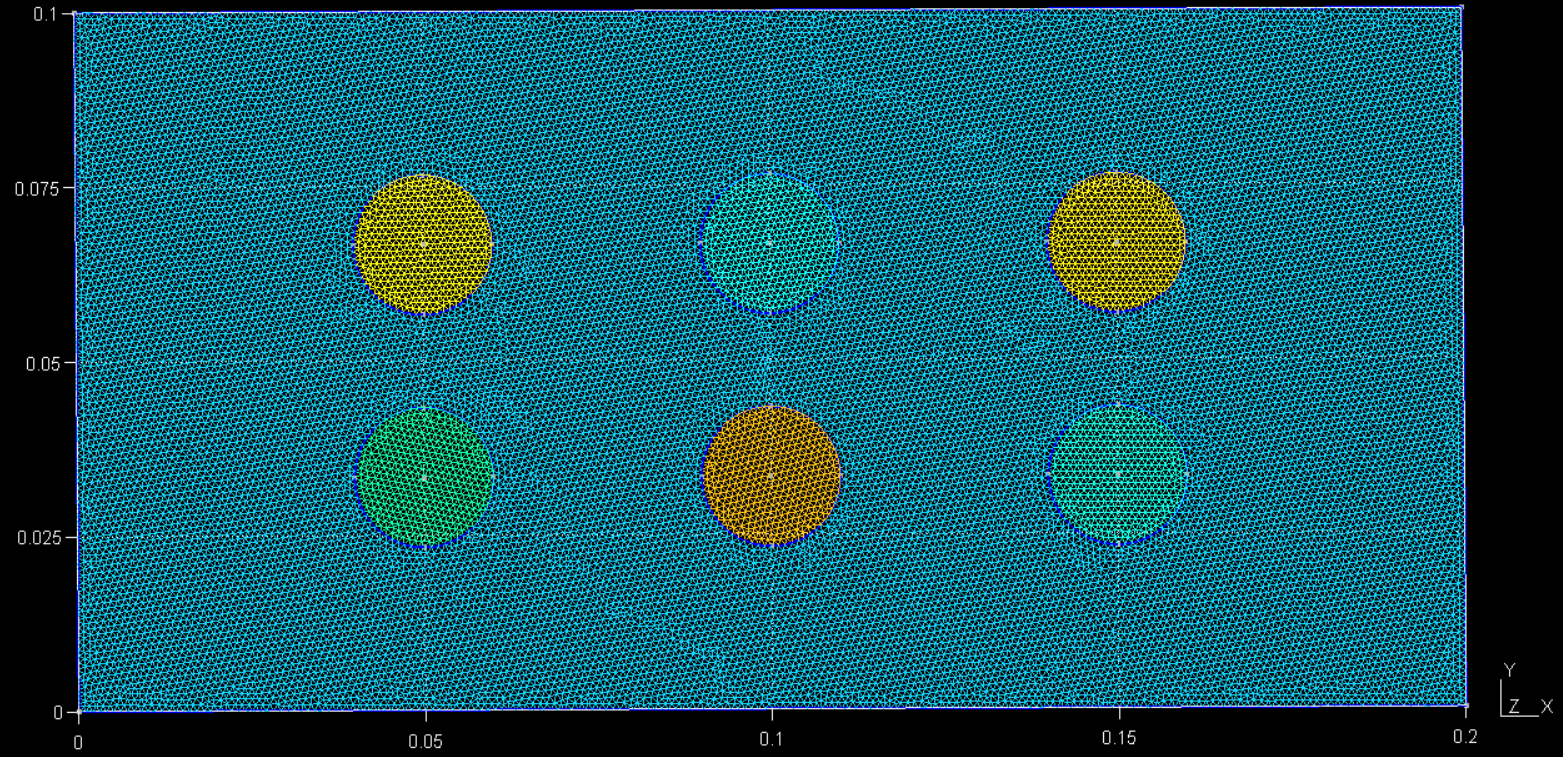 | 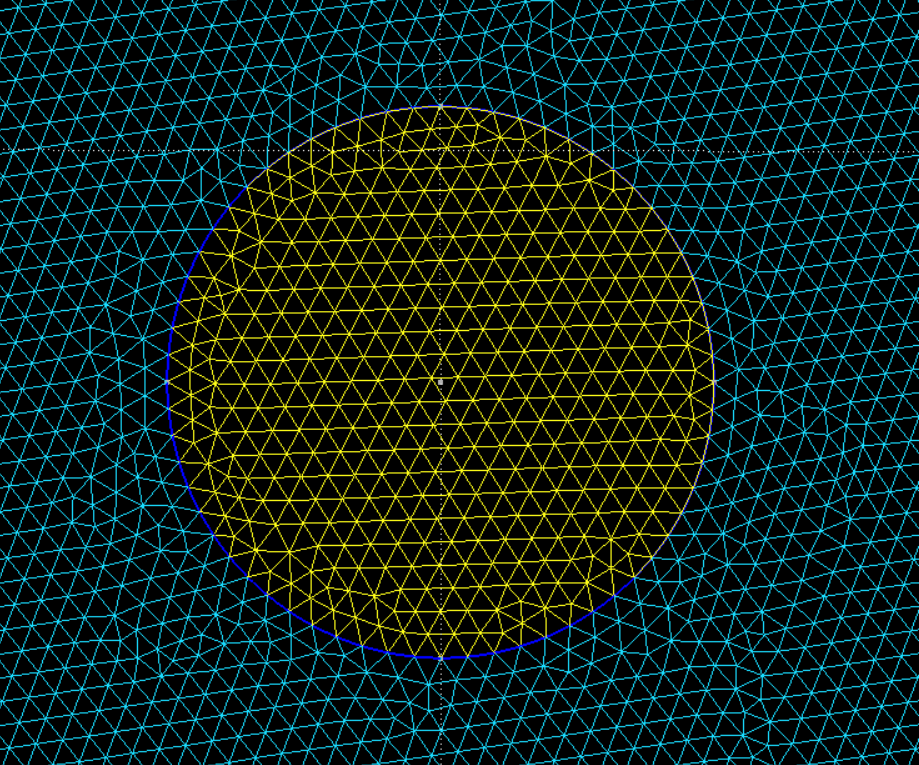 |

### COPPER HEAT EXCHANGER SCRIPT

In [1]:
#!/usr/bin/env python
"""
Transient 2D heat diffusion using explicit (forward Euler) time integration.

This example solves:

    ρ Cp (∂T/∂t) = ∇(D∇T) + s

with Dirichlet boundary conditions and optional internal heat source.
The discretization uses 2D linear diffusion elements ("heat_exchanger_2d_heat"),
a lumped mass matrix, and a forward-Euler update:

    T^{n+1} = T^n + dt * M_lumped^{-1} (F^n - K T^n)

Notes:
    - Governing physics is Physics.HEAT_TRANSFER.
    - DOFType.TEMPERATURE is used for nodal temperature unknowns.
    - Stability automatically checks the explicit condition:

            Fo = α dt / dx² ≤ 0.5

      and raises a ValueError if violated.

Created: 2025/01/14 09:53:45
Last modified: 2026/02/09 15:30:47
Author: Francesco Bolzonella (francesco.bolzonella.1@studenti.unipd.it)
"""

import numpy as np

import pyfem
from pyfem.solvers import DiffusionExplicitSolver


def main() -> np.ndarray:
    # PREPROCESSING

    # 1. Build mesh from Gmsh
    mesh = pyfem.Mesh.from_gmsh("heat_exchanger.msh", dim=2)

    # 2. Materials
    # rho   = density [kg/m³]
    # c     = specific heat capacity [J/(kg*K)]
    # k     = thermal conductivity [W/(m*K)]
    # alpha = k / (rho * c) = thermal diffusivity [m²/s]

    # Steel  -> AISI 316L (EN 1.4404)
    # Copper -> Copper DHP (UNS C12200 / CW024A)
    # Water  -> tap water

    materials = pyfem.make_materials(
        [
            (
                "water",
                pyfem.Diffusion2D(
                    rho=1000.0, c=4182.0, k=0.6, alpha=(1000.0 / (0.6 * 4184.0))
                ),
            ),
            (
                "copper",
                pyfem.Diffusion2D(
                    rho=8940.0, c=385.0, k=340.0, alpha=(340.0 / (8940.0 * 385.0))
                ),
            ),
        ]
    )

    # 3. Define element properties registry
    element_properties = pyfem.make_element_properties(
        [
            (
                "matrix",
                pyfem.ElementProperty(
                    kind="triangle_heat",
                    params={"source": 0.0, "t": 1.0},  # °C/s , m
                    material="copper",
                    meta={"integration": 1},
                ),
            ),
            (
                "tube_hot",
                pyfem.ElementProperty(
                    kind="triangle_heat",
                    params={"source": 0.0, "t": 1.0},  # °C/s , m
                    material="water",
                    meta={"integration": 1},
                ),
            ),
            (
                "tube_cold",
                pyfem.ElementProperty(
                    kind="triangle_heat",
                    params={"source": 0.0, "t": 1.0},  # °C/s , m
                    material="water",
                    meta={"integration": 1},
                ),
            ),
        ]
    )

    # 4. Create Model
    problem = pyfem.Problem(
        pyfem.Physics.HEAT_TRANSFER,
        pyfem.Dimension.D2,
    )
    model = pyfem.Model(mesh, problem)
    model.set_materials(materials)
    model.set_element_properties(element_properties)
    print(model)

    # Initial temperature T0(x)
    ndofs = model.dof_space.total_dofs
    points = mesh.points
    T0 = np.zeros(ndofs, dtype=float)

    s = 0.01  # scale factor (from m to cm)

    for node, coords in enumerate(points):
        dof = model.dof_space.get_global_dof(node, pyfem.DOFType.TEMPERATURE)

        # 1. Extract actual node coordinates x and y
        x_node, y_node = coords[0], coords[1]

        # 2. Distance from tube centers
        # 2nd tube centered at (10.0, 3.33) with radius 1.0 (cm)
        dist_tube_2 = np.sqrt((x_node - 10.0 * s) ** 2 + (y_node - 3.33 * s) ** 2)
        # 4th tube centered at (15.0, 6.66) with radius 1.0 (cm)
        dist_tube_4 = np.sqrt((x_node - 15.0 * s) ** 2 + (y_node - 6.66 * s) ** 2)
        # 6th tube centered at (5.0, 6.66) with radius 1.0 (cm)
        dist_tube_6 = np.sqrt((x_node - 5.0 * s) ** 2 + (y_node - 6.66 * s) ** 2)

        # 3. Set initial temperature based on distance from tube centers
        tube_radius = 1.0 * s
        if (
            (dist_tube_2 <= tube_radius)
            or (dist_tube_4 <= tube_radius)
            or (dist_tube_6 <= tube_radius)
        ):
            T0[dof] = 80.0  # Hot tube temperature
        else:
            T0[dof] = 20.0  # Matrix and cold tube temperature

    model.set_initial_temperature(T0)

    # 6. Boundary conditions

    # Dirichlet BCs: prescribed temperatures
    model.bc.prescribe_dirichlet("cold_surface", pyfem.DOFType.TEMPERATURE, 20.0)
    model.bc.prescribe_dirichlet("hot_surface", pyfem.DOFType.TEMPERATURE, 80.0)

    # No Neumann flux boundary conditions here.

    model.bc.print_summary()

    # PROCESSING: Solve transient diffusion problem

    # Time discretization parameters
    total_time = 10.0  # total physical time in seconds

    # STABILITY CHECK FOR EXPLICIT SCHEME (Fourier number)
    #
    solver = DiffusionExplicitSolver(model)
    dt_crit = solver.compute_critical_timestep_2D()
    dt = dt_crit * 0.75  # use 75% of critical time step for stability
    increments = int((total_time / dt))
    is_stable = solver.check_stability(dt, verbose=True)
    # ------------------------------------------------------------------

    # Initialize model state
    model_state = pyfem.ModelState()

    # Define explicit diffusion step
    step = pyfem.Step(
        name="HeatExplicit",
        procedure=pyfem.ProcedureType.DIFFUSION_EXPLICIT,
        increments=increments,
        total_time=total_time,
        verbose=True,
        output_fields=["temperature"],
        output_frequency=int(increments / 20.0),  # dump every nth time step
        output_save_to="vtk_heat_results_copper",  # folder
        output_file="heat_step_copper.vtu",  # base name
    )

    # use the warp by scalar filter in paraview to see the temperature profile

    # Execute step (returns updated state)
    model_state = step.execute(model, model_state)

    # POSTPROCESSING: statistics filtered only for the matrix region

    T_final = model_state.current_solution.temperature

    # Let's find the indices of the elements that are labeled as "matrix"
    #    mesh.element_property_labels is a list that says "matrix", "tube_hot", ecc. for each element
    matrix_element_indices = [
        i for i, label in enumerate(mesh.element_property_labels) if label == "matrix"
    ]

    # Let's find the unique nodes that belong to these "matrix" elements
    #    set counteracts duplications (each node is shared by multiple triangles)
    matrix_nodes = set()
    for elem_idx in matrix_element_indices:
        nodes = mesh.element_connectivity[elem_idx]
        matrix_nodes.update(nodes)

    # List conversion for indexing
    matrix_nodes_list = list(matrix_nodes)

    # Let's extract the T values only for these nodes
    T_matrix = T_final[matrix_nodes_list]

    # Let's compute the heat fluxes at the end of the simulation
    F_reaction, power_in, power_out, balance = solver.compute_heat_flux(T_final)

    # Let's print the results
    print("\n" + "=" * 40)
    print(f"RESULTS FOR REGION: MATRIX ({element_properties['matrix'].material})")
    print("=" * 40)
    print(f"  Nodes in matrix:     {len(T_matrix)} (out of {len(T_final)})")
    print(f"  Min Temperature:     {np.min(T_matrix):.4f} °C")
    print(f"  Max Temperature:     {np.max(T_matrix):.4f} °C")
    print(f"  Avg Temperature:     {np.mean(T_matrix):.4f} °C")
    print(f"  Total time ():    {total_time} sec")
    print(f"  Time between dumps:  {total_time / 20} sec")
    print(
        "  Note: Tubes and water regions are excluded from these stats because the T is constant."
    )
    print("-" * 40)
    print("\n" + "=" * 40)
    print(f" HEAT FLUX ANALYSIS (after {(total_time / 60.0)} min)")
    print("=" * 40)
    print(f"  Total Power INPUT  (Hot Source): {power_in:10.4f} W")
    print(f"  Total Power OUTPUT (Cold Sink):  {power_out:10.4f} W")
    print("-" * 40)
    print(f"  Global Balance (Net Flux):       {balance:10.4e} W")
    print("=" * 40 + "\n")
    print("  Full field results saved to: 'vtk_heat_results/*.vtu'")
    print("  Open with Paraview to visualize.")
    print("=" * 40 + "\n")

    return T_final


if __name__ == "__main__":
    main()




Model Summary:
  Problem Type: Heat Transfer (2D) - DOFs: [temperature]
  Mesh: 24164 nodes, 47726 elements
  Degrees of Freedom: 24164
  Node Sets: 3

================= BOUNDARY CONDITIONS =================

 Prescribed Values (Dirichlet):
   - Type: TEMPERATURE  | Value: 20         | Applied to   192 nodes (4, 5, 6, 7, 12...)
   - Type: TEMPERATURE  | Value: 80         | Applied to   192 nodes (8, 9, 10, 11, 16...)

 Applied Forces (Neumann):
   None


STABILITY CHECK: Forward Euler Time Stepping
  Critical time step:        7.146e-04 s (0.00 hours)
  Requested time step:       5.360e-04 s (0.00 hours)
  Stability ratio (Δt/Δt_c): 0.750
  Status: ✓ STABLE

EXECUTING STEP: HeatExplicit
  Procedure: DIFFUSION_EXPLICIT

Model Summary:
  Problem Type: Heat Transfer (2D) - DOFs: [temperature]
  Mesh: 24164 nodes, 47726 elements
  Degrees of Freedom: 24164
  Node Sets: 3
[HeatExplicit] Diffusion explicit: t0=0.0, t1=10.0, dt=0.0005359918529238356
INFO: Static sources detected (numbers). 

### STEEL HEAT EXCHANGER SCRIPT

In [2]:
#!/usr/bin/env python

import numpy as np

import pyfem
from pyfem.solvers import DiffusionExplicitSolver


def main() -> np.ndarray:
    # PREPROCESSING

    # 1. Build mesh from Gmsh
    mesh = pyfem.Mesh.from_gmsh("heat_exchanger.msh", dim=2)

    # 2. Materials
    # rho   = density [kg/m³]
    # c     = specific heat capacity [J/(kg*K)]
    # k     = thermal conductivity [W/(m*K)]
    # alpha = k / (rho * c) = thermal diffusivity [m²/s]

    # Steel  -> AISI 316L (EN 1.4404)
    # Copper -> Copper DHP (UNS C12200 / CW024A)
    # Water  -> tap water

    materials = pyfem.make_materials(
        [
            (
                "steel",
                pyfem.Diffusion2D(
                    rho=8000.0, c=500.0, k=15.0, alpha=(15.0 / (8000.0 * 500.0))
                ),
            ),
            (
                "water",
                pyfem.Diffusion2D(
                    rho=1000.0, c=4182.0, k=0.6, alpha=(0.6 / (1000.0 * 4184.0))
                ),
            ),
        ]
    )

    # 3. Define element properties registry
    element_properties = pyfem.make_element_properties(
        [
            (
                "matrix",
                pyfem.ElementProperty(
                    kind="triangle_heat",
                    params={"source": 0.0, "t": 1.0},  # °C/s , m
                    material="steel",
                ),
            ),
            (
                "tube_hot",
                pyfem.ElementProperty(
                    kind="triangle_heat",
                    params={"source": 0.0, "t": 1.0},  # °C/s , m
                    material="water",
                ),
            ),
            (
                "tube_cold",
                pyfem.ElementProperty(
                    kind="triangle_heat",
                    params={"source": 0.0, "t": 1.0},  # °C/s , m
                    material="water",
                ),
            ),
        ]
    )

    # 4. Create Model
    problem = pyfem.Problem(
        pyfem.Physics.HEAT_TRANSFER,
        pyfem.Dimension.D2,
    )
    model = pyfem.Model(mesh, problem)
    model.set_materials(materials)
    model.set_element_properties(element_properties)
    print(model)

    # Initial temperature T0(x)
    ndofs = model.dof_space.total_dofs
    points = mesh.points
    T0 = np.zeros(ndofs, dtype=float)

    s = 0.01  # scale factor (from m to cm)

    for node, coords in enumerate(points):
        dof = model.dof_space.get_global_dof(node, pyfem.DOFType.TEMPERATURE)

        # 1. Extract actual node coordinates x and y
        x_node, y_node = coords[0], coords[1]

        # 2. Distance from tube centers
        # 2nd tube centered at (10.0, 3.33) with radius 1.0 (cm)
        dist_tube_2 = np.sqrt((x_node - 10.0 * s) ** 2 + (y_node - 3.33 * s) ** 2)
        # 4th tube centered at (15.0, 6.66) with radius 1.0 (cm)
        dist_tube_4 = np.sqrt((x_node - 15.0 * s) ** 2 + (y_node - 6.66 * s) ** 2)
        # 6th tube centered at (5.0, 6.66) with radius 1.0 (cm)
        dist_tube_6 = np.sqrt((x_node - 5.0 * s) ** 2 + (y_node - 6.66 * s) ** 2)

        # 3. Set initial temperature based on distance from tube centers
        tube_radius = 1.0 * s
        if (
            (dist_tube_2 <= tube_radius)
            or (dist_tube_4 <= tube_radius)
            or (dist_tube_6 <= tube_radius)
        ):
            T0[dof] = 80.0  # Hot tube temperature
        else:
            T0[dof] = 20.0  # Matrix and cold tube temperature

    model.set_initial_temperature(T0)

    # 6. Boundary conditions

    # Dirichlet BCs: prescribed temperatures
    model.bc.prescribe_dirichlet("cold_surface", pyfem.DOFType.TEMPERATURE, 20.0)
    model.bc.prescribe_dirichlet("hot_surface", pyfem.DOFType.TEMPERATURE, 80.0)

    # No Neumann flux boundary conditions here.

    model.bc.print_summary()

    # PROCESSING: Solve transient diffusion problem

    # Time discretization parameters
    total_time = 10.0  # total physical time in seconds

    # STABILITY CHECK FOR EXPLICIT SCHEME (Fourier number)
    #
    solver = DiffusionExplicitSolver(model)
    dt_crit = solver.compute_critical_timestep_2D()
    dt = dt_crit * 0.75  # use 75% of critical time step for stability
    increments = int((total_time / dt))
    is_stable = solver.check_stability(dt, verbose=True)
    # ------------------------------------------------------------------

    # Initialize model state
    model_state = pyfem.ModelState()

    # Define explicit diffusion step
    step = pyfem.Step(
        name="HeatExplicit",
        procedure=pyfem.ProcedureType.DIFFUSION_EXPLICIT,
        increments=increments,
        total_time=total_time,
        verbose=True,
        output_fields=["temperature"],
        output_frequency=int(increments / 20.0),  # dump every nth time step
        output_save_to="vtk_heat_results_steel",  # folder
        output_file="heat_step_steel.vtu",  # base name
    )

    # use the warp by scalar filter in paraview to see the temperature profile

    # Execute step (returns updated state)
    model_state = step.execute(model, model_state)

    # POSTPROCESSING: statistics filtered only for the matrix region

    T_final = model_state.current_solution.temperature

    # Let's find the indices of the elements that are labeled as "matrix"
    #    mesh.element_property_labels is a list that says "matrix", "tube_hot", ecc. for each element
    matrix_element_indices = [
        i for i, label in enumerate(mesh.element_property_labels) if label == "matrix"
    ]

    # Let's find the unique nodes that belong to these "matrix" elements
    #    set counteracts duplications (each node is shared by multiple triangles)
    matrix_nodes = set()
    for elem_idx in matrix_element_indices:
        nodes = mesh.element_connectivity[elem_idx]
        matrix_nodes.update(nodes)

    # List conversion for indexing
    matrix_nodes_list = list(matrix_nodes)

    # Let's extract the T values only for these nodes
    T_matrix = T_final[matrix_nodes_list]

    # Let's compute the heat fluxes at the end of the simulation
    F_reaction, power_in, power_out, balance = solver.compute_heat_flux(T_final)

    # Let's print the results
    print("\n" + "=" * 40)
    print(f"RESULTS FOR REGION: MATRIX ({element_properties['matrix'].material})")
    print("=" * 40)
    print(f"  Nodes in matrix:     {len(T_matrix)} (out of {len(T_final)})")
    print(f"  Min Temperature:     {np.min(T_matrix):.4f} °C")
    print(f"  Max Temperature:     {np.max(T_matrix):.4f} °C")
    print(f"  Avg Temperature:     {np.mean(T_matrix):.4f} °C")
    print(f"  Total time (sec):    {total_time} sec")
    print(f"  Time between dumps:  {total_time / 20} sec")
    print(
        "  Note: Tubes and water regions are excluded from these stats because the T is constant."
    )
    print("-" * 40)
    print("\n" + "=" * 40)
    print(f" HEAT FLUX ANALYSIS (after {(total_time / 60.0)} min)")
    print("=" * 40)
    print(f"  Total Power INPUT  (Hot Source): {power_in:10.4f} W")
    print(f"  Total Power OUTPUT (Cold Sink):  {power_out:10.4f} W")
    print("-" * 40)
    print(f"  Global Balance (Net Flux):       {balance:10.4e} W")
    print("=" * 40 + "\n")
    print("  Full field results saved to: 'vtk_heat_results/*.vtu'")
    print("  Open with Paraview to visualize.")
    print("=" * 40 + "\n")

    return T_final


if __name__ == "__main__":
    main()




Model Summary:
  Problem Type: Heat Transfer (2D) - DOFs: [temperature]
  Mesh: 24164 nodes, 47726 elements
  Degrees of Freedom: 24164
  Node Sets: 3

================= BOUNDARY CONDITIONS =================

 Prescribed Values (Dirichlet):
   - Type: TEMPERATURE  | Value: 20         | Applied to   192 nodes (4, 5, 6, 7, 12...)
   - Type: TEMPERATURE  | Value: 80         | Applied to   192 nodes (8, 9, 10, 11, 16...)

 Applied Forces (Neumann):
   None


STABILITY CHECK: Forward Euler Time Stepping
  Critical time step:        1.882e-02 s (0.00 hours)
  Requested time step:       1.412e-02 s (0.00 hours)
  Stability ratio (Δt/Δt_c): 0.750
  Status: ✓ STABLE

EXECUTING STEP: HeatExplicit
  Procedure: DIFFUSION_EXPLICIT

Model Summary:
  Problem Type: Heat Transfer (2D) - DOFs: [temperature]
  Mesh: 24164 nodes, 47726 elements
  Degrees of Freedom: 24164
  Node Sets: 3
[HeatExplicit] Diffusion explicit: t0=0.0, t1=10.0, dt=0.014124293785310734
INFO: Static sources detected (numbers). O

## Results

The FEM analysis shows the expected physical behavior. The final result is shown below, and in particular the heat diffuses radially from the hotter tubes to the colder ones and the matrix. The simulation was carried out for a total time of 10 seconds, with the results that were saved in `.vtu` files every 0.5 seconds, giving a total of 20 steps.

The final temperature distribution visualized in Paraview at $t = 10 \text{ s}$ is shown in **Figure 2** for steel and **Figure 3** for copper.

#### Figure 2 (Steel):
| a) Result | b) Enlargement |
|:---:|:---:|
| 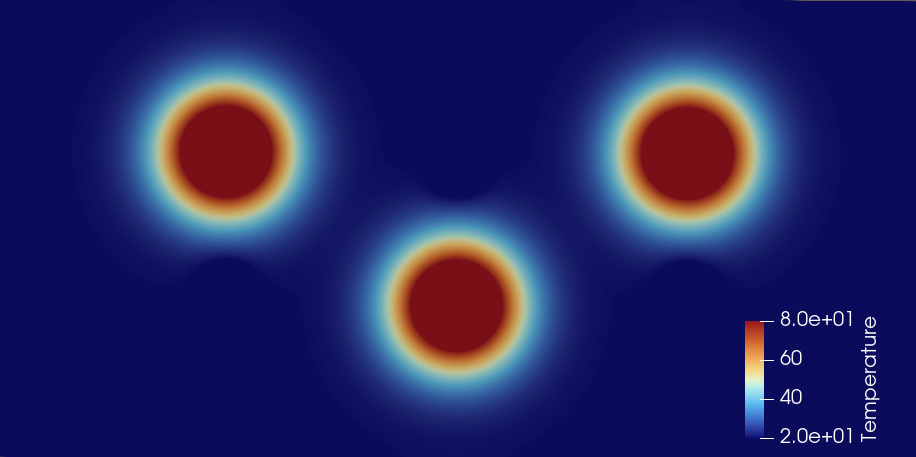 | 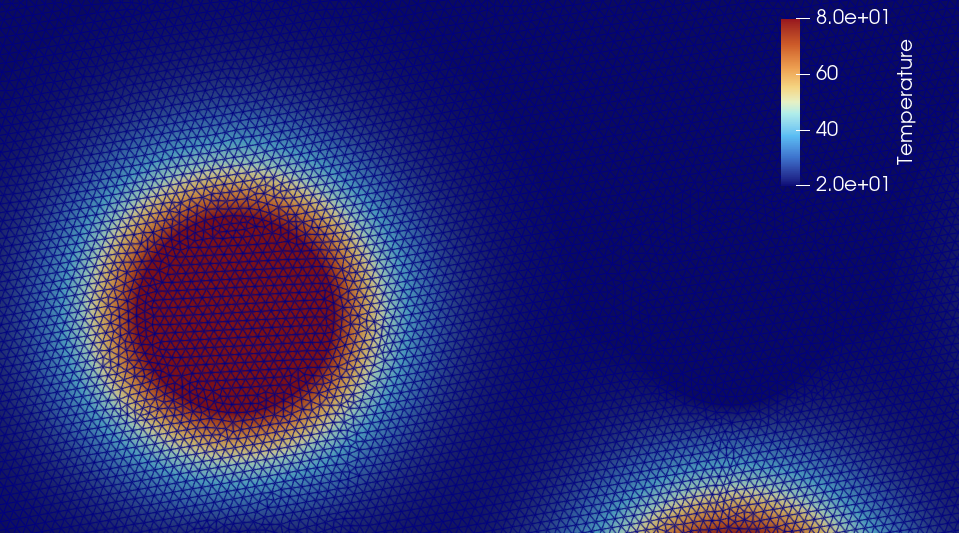 |

#### Figure 3 (Copper):
| a) Result | b) Enlargement |
|:---:|:---:|
| 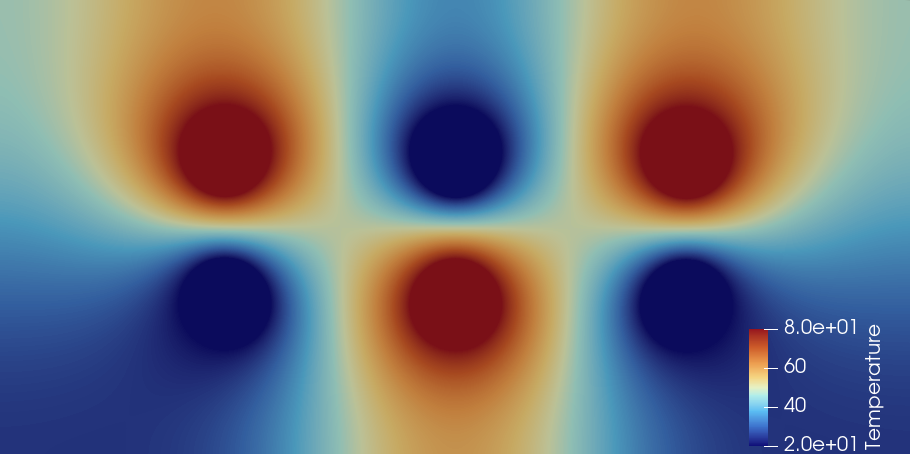 | 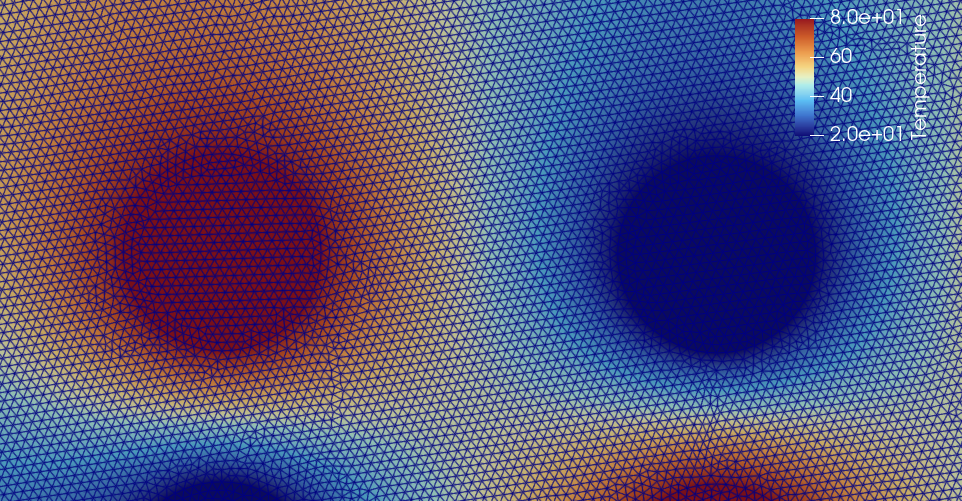 |

## Comparison and Conclusions

It is evident that the heat distribution in the copper matrix is much more homogeneous. This is expected, because copper has a thermal conductivity ($k$) almost 23 times higher than stainless steel.

Other data that highlight the better performances of the copper alloy are the average matrix temperature and the exchanged heat fluxes. After 10 seconds, the copper matrix reaches an average temperature of **44.7090 °C** and an exchanged power of **220,599.8 W** (**Figure 4**), on the other hand, the steel matrix reaches an average temperature of **25.5573 °C** and an exchanged power of **23,118.3 W** (**Figure 5**).

For a symmetric domain with 80°C and 20°C boundaries, the theoretical steady-state average temperature is 50°C. An average temperature closer to 50°C in the copper matrix means that it is approaching the steady-state thermal equilibrium much faster, and the higher heat transfer efficiency of the copper is emphasized by the increased input and output power that the simulation shows.

#### Figure 4:
| Copper statistics |
|:---:|
| 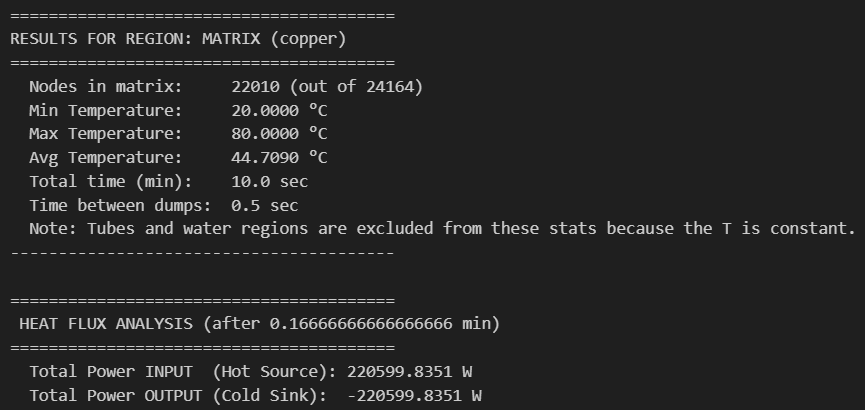 |


#### Figure 5:
| Steel statistics |
|:---:|
| 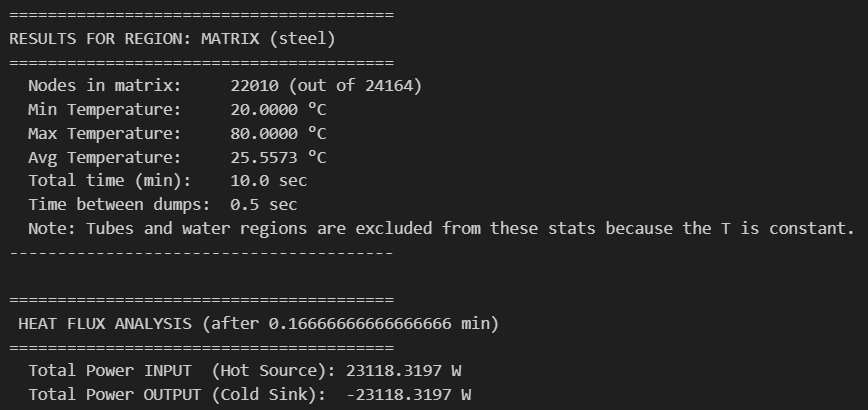 |